In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/clean_investor_transactions.csv")

print(df.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [5]:
print(df['age_group'].unique())

age_analysis = df.groupby('age_group')['amount_inr'].sum().reset_index()
print(age_analysis)

age_order = ['18-25', '26-35', '36-45', '46-55', '56+']

df['age_group'] = pd.Categorical(
    df['age_group'],
    categories=age_order,
    ordered=True
)

['56+' '18-25' '36-45' '26-35' '46-55']
  age_group  amount_inr
0     18-25   531639392
1     26-35  1451600218
2     36-45   871647528
3     46-55   405406469
4       56+   261286823


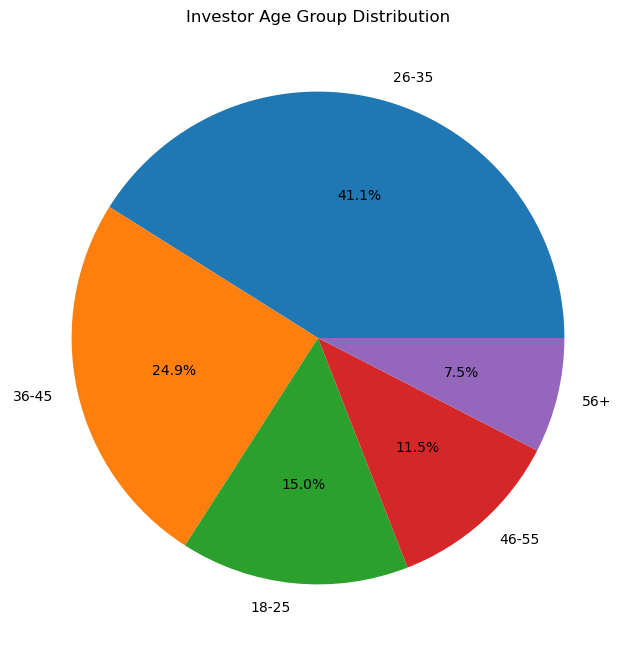

In [7]:
age_counts = df['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")

plt.show()

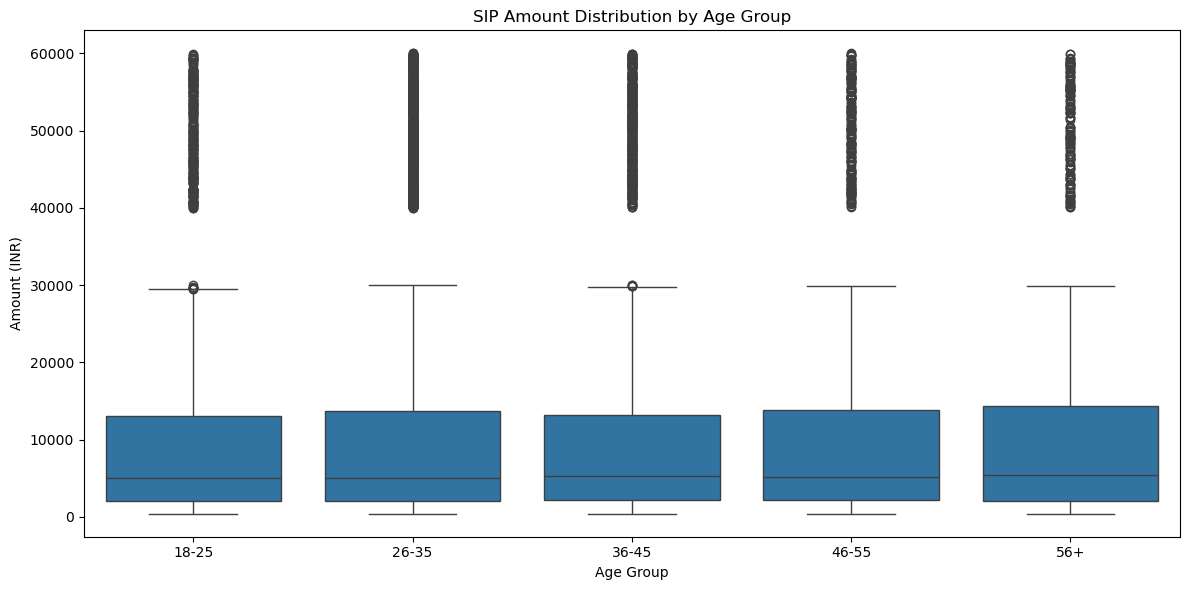

In [9]:
sip_df = df[df['transaction_type'] == 'SIP']

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='age_group',
    y='amount_inr',        # ← fixed
    data=sip_df,
    order=['18-25', '26-35', '36-45', '46-55', '56+']  # proper age order
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/clean_investor_transactions.csv")

sip_df = df[df['transaction_type'] == 'SIP']

print(df.columns.tolist())
print(df.head(2))

state_sip = sip_df.groupby('state')['amount_inr'].sum()

state_sip = state_sip.sort_values()

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   

       state       city city_tier age_group  gender  annual_income_lakh  \
0  Telangana  Hyderabad       T30       56+  Female                77.1   
1     Punjab   Amritsar       B30     18-25    Male                 7.1   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  


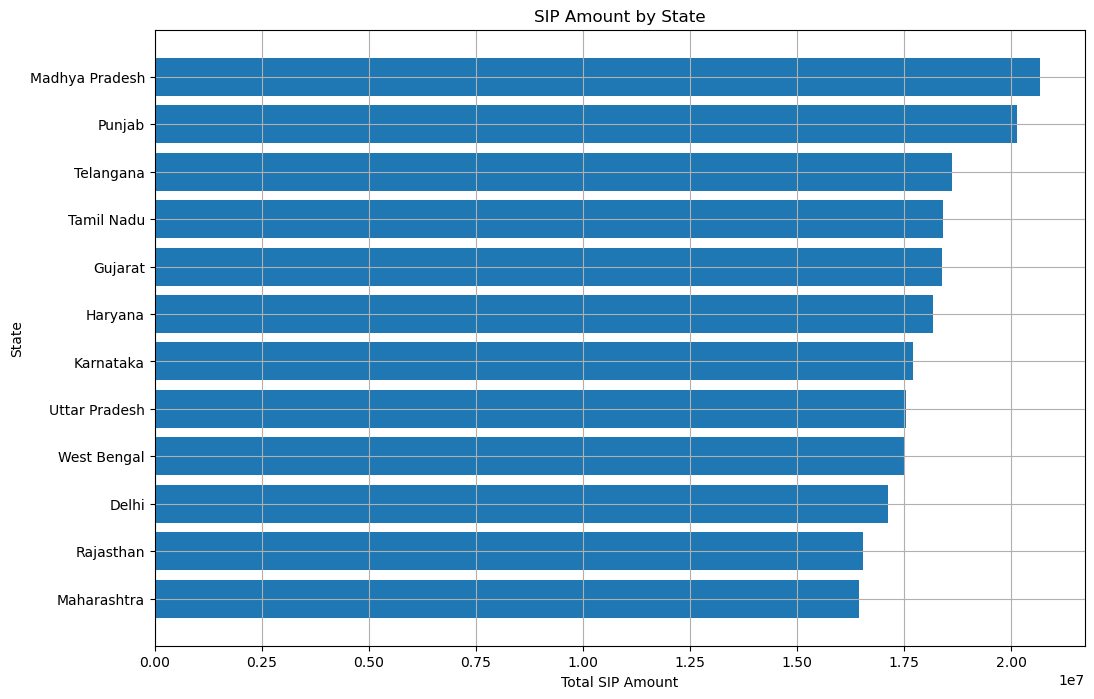

In [6]:
plt.figure(figsize=(12,8))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount")
plt.ylabel("State")

plt.grid(True)

plt.show()

In [12]:
city_tier = sip_df.groupby(
    'city_tier'
)['amount_inr'].sum()

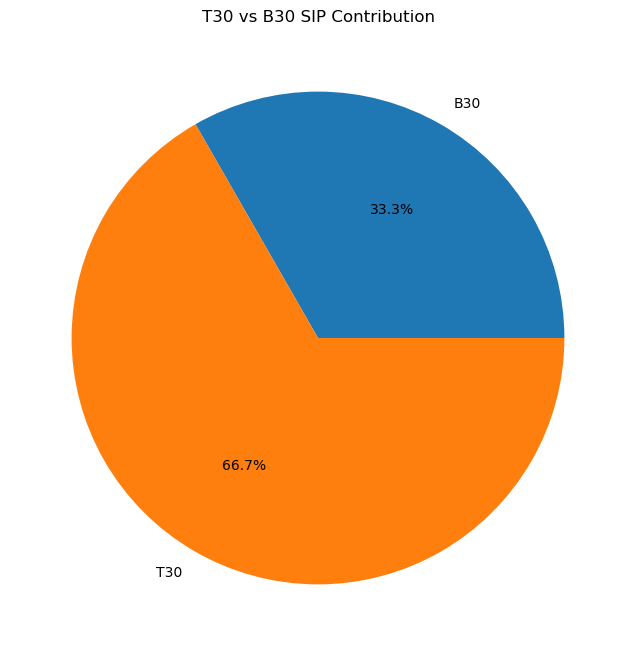

In [13]:
plt.figure(figsize=(8,8))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 SIP Contribution")

plt.show()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

equity_df = df.copy()

print(df.info)
sector_distribution = equity_df.groupby(
    'sector'
)['weight_pct'].sum()

<bound method DataFrame.info of      amfi_code stock_symbol                 stock_name       sector  \
0       119551    POWERGRID     Power Grid Corporation    Utilities   
1       119551     HDFCBANK              HDFC Bank Ltd      Banking   
2       119551       GRASIM      Grasim Industries Ltd  Diversified   
3       119551      DRREDDY   Dr. Reddy's Laboratories       Pharma   
4       119551   ASIANPAINT           Asian Paints Ltd       Paints   
..         ...          ...                        ...          ...   
317     149324     DIVISLAB        Divi's Laboratories       Pharma   
318     149324   BHARTIARTL          Bharti Airtel Ltd      Telecom   
319     149324          TCS  Tata Consultancy Services           IT   
320     149324   INDUSINDBK          IndusInd Bank Ltd      Banking   
321     149324         NTPC                   NTPC Ltd    Utilities   

     weight_pct  market_value_cr  current_price_inr portfolio_date  
0         13.85           737.09            60

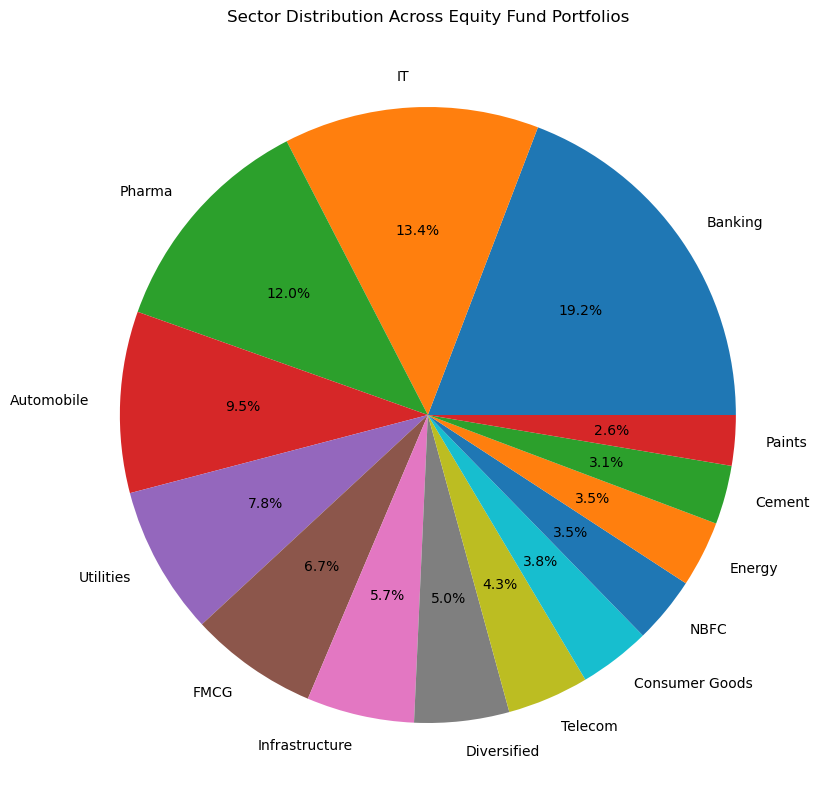

In [23]:
sector_distribution = sector_distribution.sort_values(
    ascending=False
)
plt.figure(figsize=(10,10))

plt.pie(
    sector_distribution,
    labels=sector_distribution.index,
    autopct='%1.1f%%'
)

plt.title("Sector Distribution Across Equity Fund Portfolios")

plt.show()